<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 20px; border-radius: 10px; text-align: center; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">IRIS Flower Classification using TensorFlow</p>


![image.png](https://miro.medium.com/v2/resize:fit:1200/1*S2GII1ul0JjbZ0YaFvDByw.jpeg)

<p style="color:  #8a4baf; font-size: 20px; padding: 20px; border-radius: 10px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">The Iris dataset is a well-known and frequently used benchmark in the field of machine learning and statistics. It is a classic dataset that contains a collection of measurements of various characteristics from three different types of iris flowers: Setosa, Versicolor, and Virginica. This dataset serves as a fundamental example for exploring and applying data analysis, classification, and pattern recognition techniques. Due to its simplicity and clarity, the Iris dataset continues to be a cornerstone for both beginners and experienced practitioners, providing insights into data exploration and algorithm evaluation.</p>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from keras import models
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential 
from tensorflow.keras.optimizers import Adam 

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score, classification_report

In [2]:
df = pd.read_csv("iris.csv")

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [5]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
df.describe() 
# performs statistical analysis on numerical features
# since the average value is more than the standard deviation, there is no outlier in any of the features here.
# all numeric features are in same scale, there might not be a need to perform scaling operation.

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.groupby("species").agg(["min","max","std","mean"]) 

sepal_length                       sepal_width                 \
                    min  max       std   mean         min  max       std   
species                                                                    
setosa              4.3  5.8  0.352490  5.006         2.3  4.4  0.379064   
versicolor          4.9  7.0  0.516171  5.936         2.0  3.4  0.313798   
virginica           4.9  7.9  0.635880  6.588         2.2  3.8  0.322497   

                  petal_length                       petal_width       \
             mean          min  max       std   mean         min  max   
species                                                                 
setosa      3.428          1.0  1.9  0.173664  1.462         0.1  0.6   
versicolor  2.770          3.0  5.1  0.469911  4.260         1.0  1.8   
virginica   2.974          4.5  6.9  0.551895  5.552         1.4  2.5   

                             
                 std   mean  
species                      
setosa      0.105386  0.246  
versicolor  0.197753  1.326  
virginica   0.274650  2.026

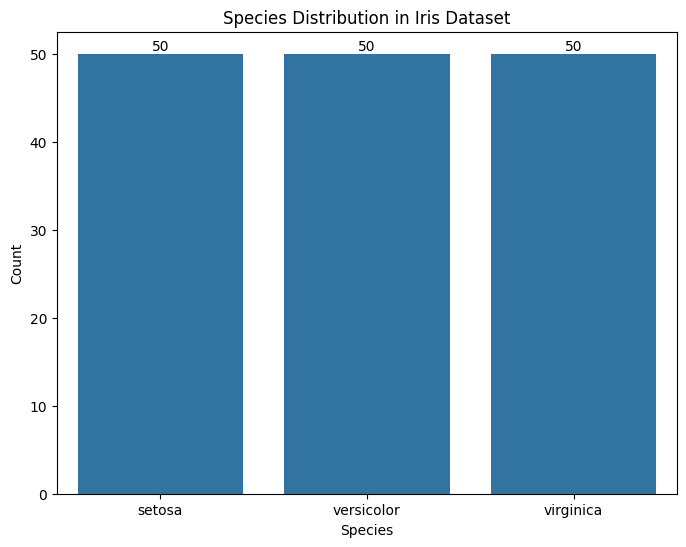

In [8]:
# check the distribution of the target variable, to see if the data is balanced or not?
plt.figure(figsize=(8, 6))
ax=sns.countplot(data=df, x='species')
ax.bar_label(ax.containers[0])
plt.title('Species Distribution in Iris Dataset')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

![](https://data-flair.training/blogs/wp-content/uploads/sites/2/2021/10/iris-flower.webp)

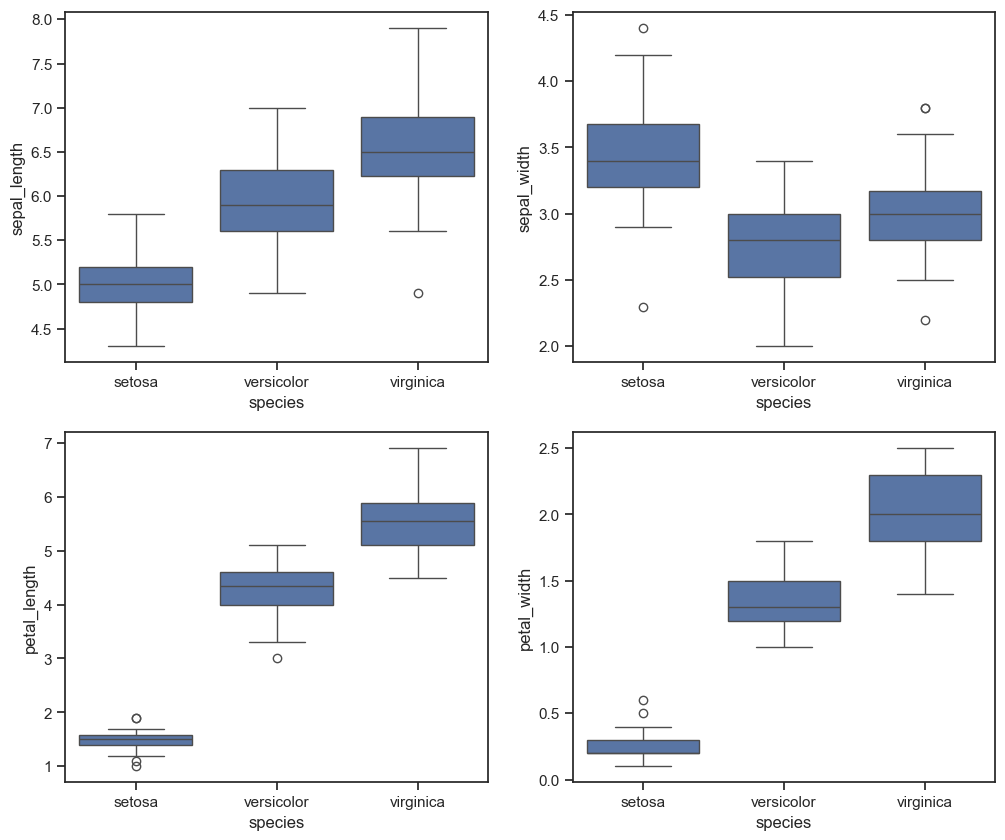

In [9]:
# box plot and pairplot are two of the most important plots for classification tasks to differentiate the classes better
# or to compare them.
sns.set(style = "ticks")
plt.figure(figsize = (12,10))

plt.subplot(2,2,1)                                                 
sns.boxplot(x = "species", y = "sepal_length", data = df)
plt.subplot(2,2,2)
sns.boxplot(x = "species", y = "sepal_width", data = df)
plt.subplot(2,2,3)
sns.boxplot(x = "species", y = "petal_length", data = df)
plt.subplot(2,2,4)
sns.boxplot(x = "species", y = "petal_width", data = df)
plt.show()
# while comparing the box plots of different classes and categories, the more apart the plots or boxes are from one another
# the better we can differentiate them


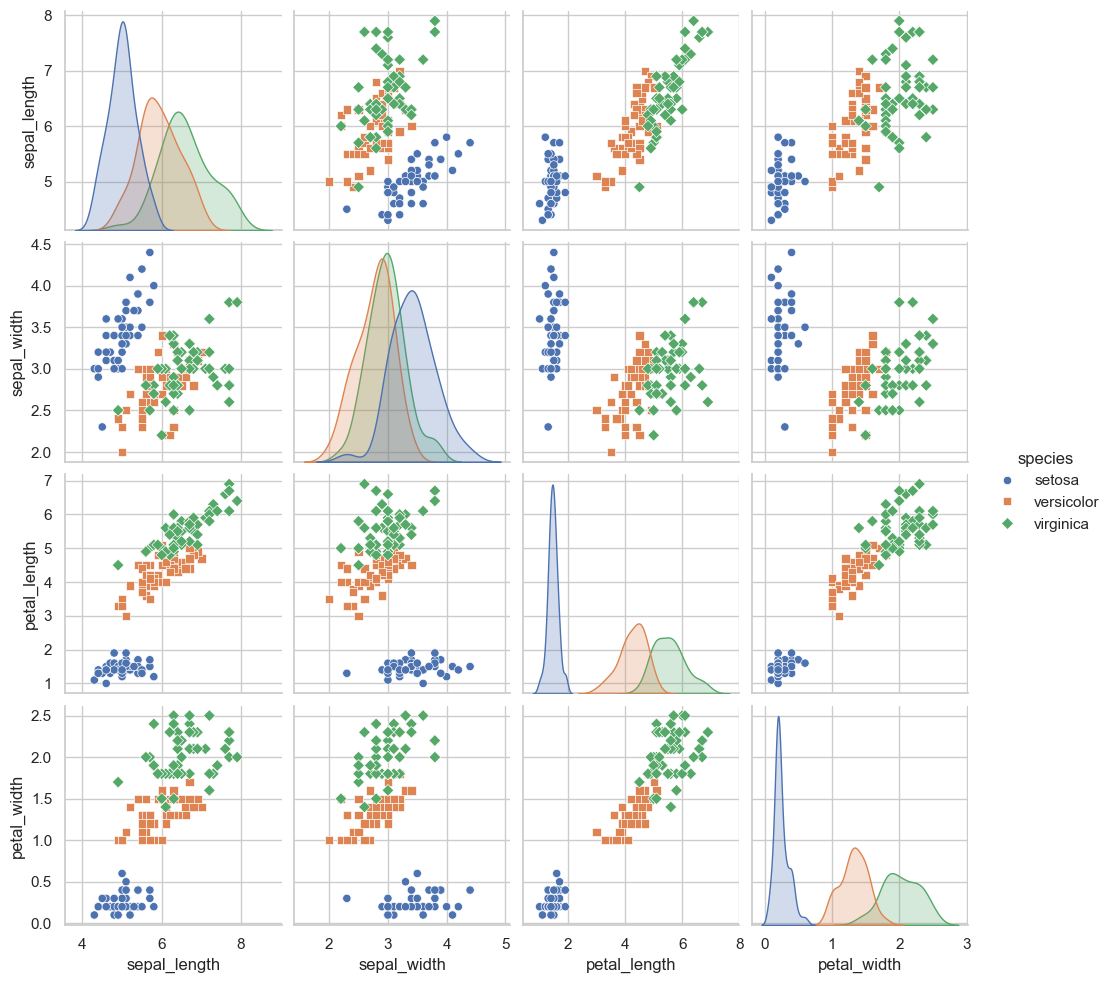

In [10]:
sns.set(style="whitegrid")

# Plot the distributions of features for each species
sns.pairplot(df, hue='species', markers=["o", "s", "D"], diag_kind="kde")
plt.show()

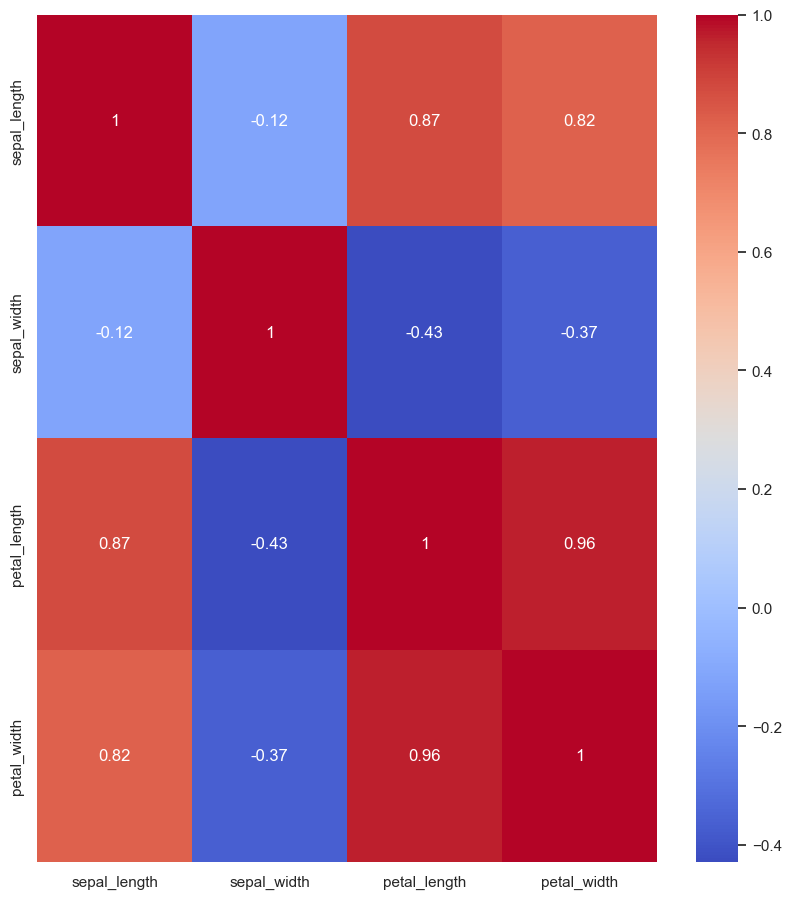

In [11]:
plt.figure(figsize = (10,11))
sns.heatmap(df.select_dtypes(include='number').corr(), annot = True, cmap = "coolwarm")
plt.show()

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


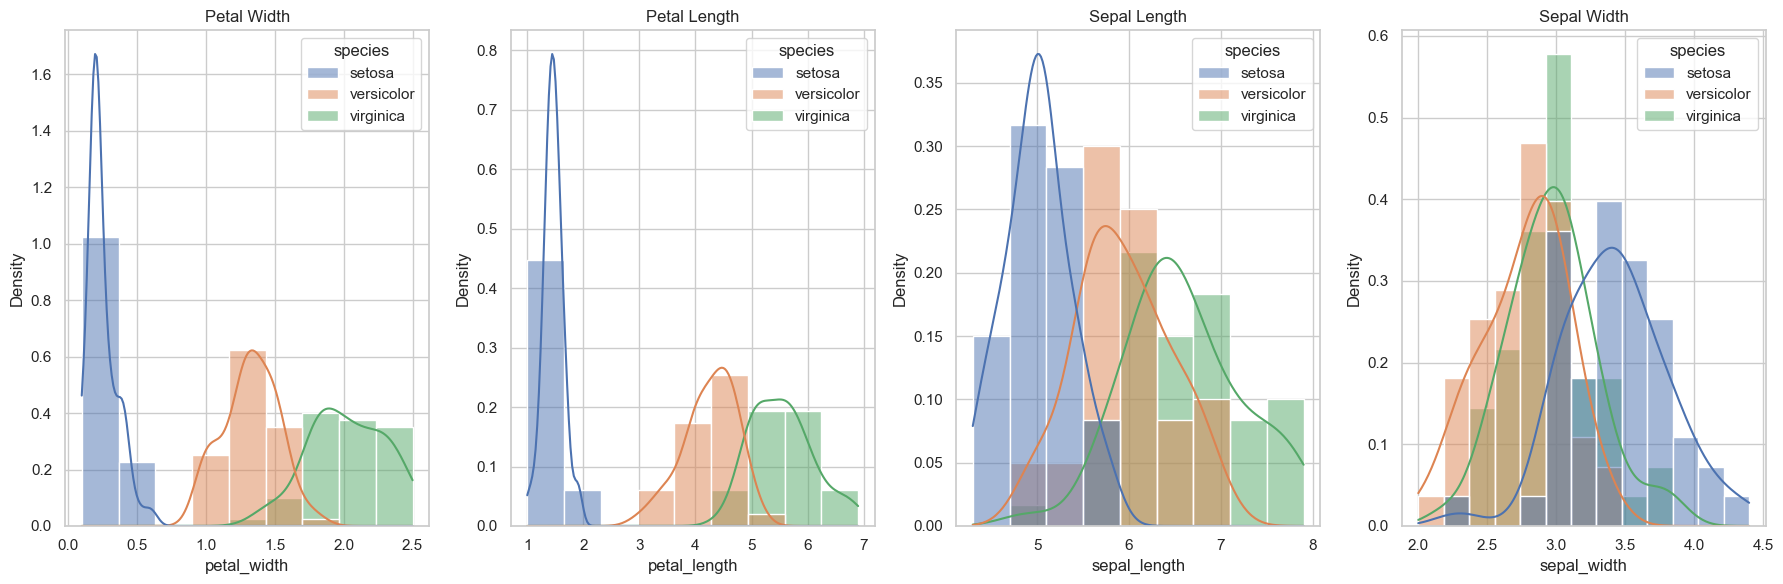

In [13]:
plt.figure(figsize=(18, 6))

# Petal width
plt.subplot(1, 4, 1)
sns.histplot(data=df, x="petal_width", hue="species", stat="density", kde=True)
plt.title("Petal Width")

# Petal length
plt.subplot(1, 4, 2)
sns.histplot(data=df, x="petal_length", hue="species", stat="density", kde=True)
plt.title("Petal Length")

# Sepal length
plt.subplot(1, 4, 3)
sns.histplot(data=df, x="sepal_length", hue="species", stat="density", kde=True)
plt.title("Sepal Length")

# Sepal width
plt.subplot(1, 4, 4)
sns.histplot(data=df, x="sepal_width", hue="species", stat="density", kde=True)
plt.title("Sepal Width")

plt.tight_layout()
plt.show()

### Results

* While we have four numerical columns, there is only one categorical column (flower species) that we aim to analyze.

* The dataset is balanced, meaning there are equal records for all three species.

* There are no missing values in our dataset.

* Based on the boxplot, and statistical analysis with df.describe we can see that there is no serious issue with outliers. As the average or mean values are less than standard deviations in each feature.

* There is a strong correlation between petal width and petal length.

* The Setosa species is the easiest to distinguish due to its smaller size.

* Versicolor and Virginica species are often confused and can sometimes be difficult to separate. However, Versicolor generally has more average-sized dimensions, whereas Virginica tends to have larger dimensions.

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# we can also use mapping to convert our categorical data to numeric as setosa:0, versicolor:1, virginica:2
# but with mapping the algorithm reads the numeric data 0, 1, 2 as numeric values, and compare them as which one is 
# higher and which one is lower, that's why we are using label encoder, to make sure that these numbers are mere
# or only labels or names, not a numeric value

In [15]:
le.fit_transform(df["species"])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [16]:
df["species"] = le.fit_transform(df["species"])

In [17]:
df["species"].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

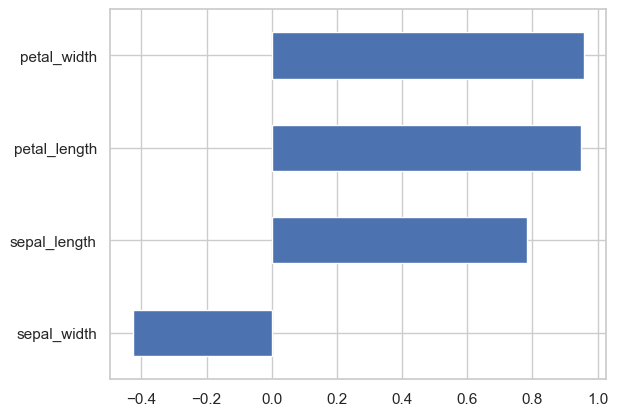

In [18]:
df.corr()['species'][:-1].sort_values().plot.barh();

In [19]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Train-Test Split

In [20]:
X = df .drop("species", axis = 1)
y = df["species"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [22]:
scaler = MinMaxScaler()
# since all four features in this dataset has same scale, there is no need to perform scaling
# but for the sake of making calculations easier for our model, we can scale them

In [23]:
X_train = scaler.fit_transform(X_train) # the fit part can only be applied on the training dataset
# just like a ml or dl algorithm
X_test = scaler.transform(X_test)

## ANN Model

#### IMPORTANT:
* If the target variables in your dataset are in the form of class numbers, meaning each class is represented by a number, it is more appropriate to use the **sparse_categorical_crossentropy** loss function. If one-hot encoding is used, then **categorical_crossentropy** is preferred. Due to the nature of our target variable, we will choose the sparse_categorical_crossentropy loss function.
* If we were to use categorical_crossentropy in our model, we would first need to import **from tensorflow.keras.utils import to_categorical**, and then apply the following on our `y` data in sequence: **y_train_encoded = to_categorical(y_train)** and **y_test_encoded = to_categorical(y_test)**.

In [24]:
# Build the model
model = Sequential([
    Dense(units=10, activation="relu"),
    Dense(units=10, activation="relu"),             # When we reduce the number of neurons, it is necessary to increase the number of epochs.
# when the architecture is simpler, or the number of neurons is less, our model takes more time to reach the ideal results
    # because of less computational power, so we need to increase the number of epochs to train our model more

    Dense(units=3, activation="softmax")            # output layer
])

opt = Adam(learning_rate=0.001)

model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
# using sparse categorical cross entropy because the target variable is a scaler value like 0, 1, or 2, not a vector like [1, 0, 0] or [0, 1, 0]
history = model.fit(x=X_train, y=y_train, 
                    validation_data=(X_test, y_test),
                    batch_size=5, epochs=200)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3250 - loss: 1.1065 - val_accuracy: 0.4000 - val_loss: 1.0999
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5417 - loss: 1.0832 - val_accuracy: 0.5667 - val_loss: 1.0760
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6250 - loss: 1.0633 - val_accuracy: 0.7000 - val_loss: 1.0536
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6583 - loss: 1.0451 - val_accuracy: 0.7000 - val_loss: 1.0340
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6583 - loss: 1.0255 - val_accuracy: 0.7000 - val_loss: 1.0101
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6583 - loss: 1.0016 - val_accuracy: 0.7000 - val_loss: 0.9814
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6583 - loss: 0.9728 - val_accuracy: 0.7000 - val_loss: 0.9469
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6583 - loss: 0.9381 - val_accuracy: 0.7000 - v

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (5, 10)                     │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (5, 10)                     │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (5, 3)                      │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 581 (2.27 KB)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 388 (1.52 KB)

* Since our data is not large or complex, we did not apply Dropout and Early Stopping methods.

In [26]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred_probabilities = model.predict(X_train)
    y_train_pred = y_train_pred_probabilities.argmax(axis=1)
    y_pred_probabilities = model.predict(X_test)
    y_pred = y_pred_probabilities.argmax(axis=1)
    
    print("Test Set:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    
    print("\nTrain Set:")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [27]:
eval_metric(model, X_train, y_train, X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Test Set:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30


Train Set:
[[40  0  0]
 [ 0 38  3]
 [ 0  2 37]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.95      0.93      0.94        41
           2       0.93      0.95      0.94        39

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



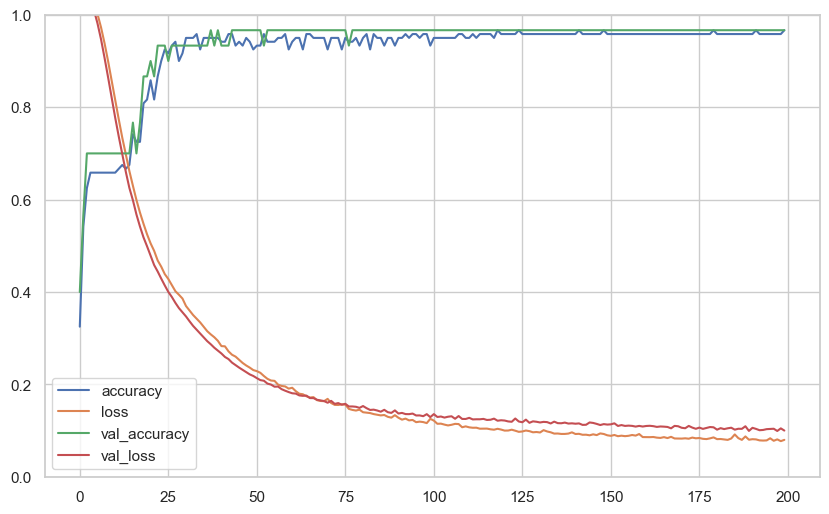

In [28]:
pd.DataFrame(history.history).plot(figsize=(10,6))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()


Accuracy during Training :
------------------------------------


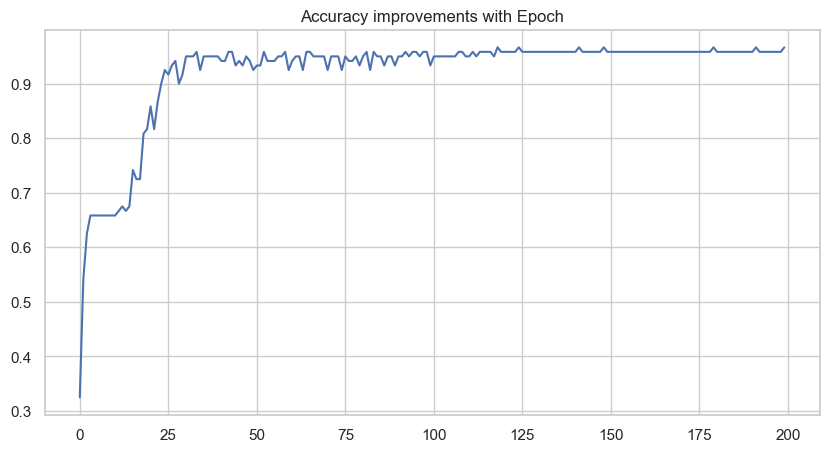

In [29]:
# let's see the change in accuracy

print("\nAccuracy during Training :\n------------------------------------")

pd.DataFrame(history.history)["accuracy"].plot(figsize=(10, 5))
plt.title("Accuracy improvements with Epoch")
plt.show()

## Final Model and Model Deployment

In [30]:
X.shape

(150, 4)

In [31]:
y.shape

(150,)

In [32]:
scaler = MinMaxScaler().fit(X)

In [33]:
# save the MinMaxScaler scaling operation
pickle.dump(scaler, open("scaler_iris", 'wb'))

In [34]:
X_scaled = scaler.transform(X)

In [35]:
final_model = Sequential([
            Dense(units=10, activation="relu"),
            Dense(units=10, activation="relu"),             # had to increase the number of epoch as the number of neurons are less
            Dense(units=3, activation="softmax")
    ])

opt = Adam(learning_rate=0.001)

final_model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

final_model.fit(x=X_scaled, y=y, batch_size=5, epochs=200) 

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3200 - loss: 1.0901   
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2400 - loss: 1.0547 
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3133 - loss: 1.0252 
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3467 - loss: 0.9918 
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5533 - loss: 0.9529 
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6267 - loss: 0.9082 
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6600 - loss: 0.8548 
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6667 - loss: 0.7945 
Epoch 9/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6667 - loss: 0.7385 
Epoch 10/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6667 - loss: 0.6910 
Epoch 11/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6667 - loss: 0.6485 
Epoch 12/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

In [36]:
final_model.save('final_model_ANN_iris.h5') 

### Prediction with the saved model

In [37]:
# creating sample data manually
my_dict = {"sepal_length": [4.5, 5.8, 7.5],
           "sepal_width": [2.2, 3, 4.2],
           "petal_length": [1.3, 4.3, 6.5],
           "petal_width": [0.2, 1.3, 2.3]}

sample_ann = pd.DataFrame(my_dict)
sample_ann

,sepal_length,sepal_width,petal_length,petal_width
0,4.5,2.2,1.3,0.2
1,5.8,3.0,4.3,1.3
2,7.5,4.2,6.5,2.3


In [38]:
# loading the min-max scaler files
scaler_iris = pickle.load(open("scaler_iris", "rb"))

In [39]:
sample_scaled = scaler_iris.transform(sample_ann)
sample_scaled

array([[0.05555556, 0.08333333, 0.05084746, 0.04166667],
       [0.41666667, 0.41666667, 0.55932203, 0.5       ],
       [0.88888889, 0.91666667, 0.93220339, 0.91666667]])

In [40]:
# load the pretrained model

from tensorflow.keras.models import load_model

In [41]:
final_model = load_model('final_model_ANN_iris.h5')

In [42]:
final_model.predict(sample_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[9.9151176e-01, 8.4580425e-03, 3.0162439e-05],
       [1.3835651e-04, 9.9775058e-01, 2.1110557e-03],
       [4.2356634e-09, 8.1773096e-04, 9.9918228e-01]], dtype=float32)

In [43]:
y_pred_probabilities = final_model.predict(sample_scaled)
y_pred = y_pred_probabilities.argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [44]:
sample_ann["pred"] = y_pred
sample_ann

,sepal_length,sepal_width,petal_length,petal_width,pred
0,4.5,2.2,1.3,0.2,0
1,5.8,3.0,4.3,1.3,1
2,7.5,4.2,6.5,2.3,2


In [45]:
predictions = final_model.predict(sample_scaled)

normalized_predictions = tf.nn.softmax(predictions, axis=-1).numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [46]:
normalized_predictions

array([[0.5730024 , 0.21439846, 0.21259913],
       [0.21214427, 0.5752926 , 0.21256319],
       [0.21200465, 0.21217808, 0.5758173 ]], dtype=float32)

In [47]:
sample_ann["pred_proba_setosa"] = normalized_predictions[:,0]
sample_ann["pred_proba_versicolor"] = normalized_predictions[:,1]
sample_ann["pred_proba_virginica"] = normalized_predictions[:,2]
sample_ann

,sepal_length,sepal_width,petal_length,petal_width,pred,pred_proba_setosa,pred_proba_versicolor,pred_proba_virginica
0,4.5,2.2,1.3,0.2,0,0.573002,0.214398,0.212599
1,5.8,3.0,4.3,1.3,1,0.212144,0.575293,0.212563
2,7.5,4.2,6.5,2.3,2,0.212005,0.212178,0.575817


## xgboost Model

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [49]:
X_train.shape

(120, 4)

In [50]:
import xgboost
import sklearn
print(f"xgboost version: {xgboost.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")


xgboost version: 3.2.0
scikit-learn version: 1.8.0


In [51]:
import xgboost as xgb
xgb_cls = xgb.XGBClassifier(objective="multi:softmax", num_class=3)


In [52]:
xgb_cls.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [53]:
preds = xgb_cls.predict(X_test)

In [54]:
preds

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0], dtype=int32)

In [55]:
np.array(y_test)

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [56]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [57]:
eval_metric(xgb_cls, X_train, y_train, X_test, y_test)

Test_Set
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Train_Set
[[40  0  0]
 [ 0 41  0]
 [ 0  0 39]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        39

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



In [58]:
from sklearn.model_selection import cross_validate

model = xgb.XGBClassifier(objective = "multiclass:softmax", num_class = 3)

scores = cross_validate(model, X_train, y_train, scoring = ['accuracy', 'precision_weighted','recall_weighted',
                                                            'f1_weighted'], cv = 20)
                                                        
df_scores = pd.DataFrame(scores, index = range(1, 21))
df_scores.mean()[2:]

test_accuracy              0.925000
test_precision_weighted    0.936111
test_recall_weighted       0.925000
test_f1_weighted           0.918333
dtype: float64

## Final Model and Model Deployment

In [59]:
final_model = xgb.XGBClassifier(objective = "multiclass:softmax", num_class = 3).fit(X, y)

In [60]:
pickle.dump(final_model, open("final_model_xgboost_iris", 'wb'))

### Prediction with  the saved model

In [61]:
my_dict = {"sepal_length": [4.5, 5.8, 7.5],
           "sepal_width": [2.2, 3, 4.2],
           "petal_length": [1.3, 4.3, 6.5],
           "petal_width": [0.2, 1.3, 2.3]}
sample_xgboost = pd.DataFrame(my_dict)
sample_xgboost

,sepal_length,sepal_width,petal_length,petal_width
0,4.5,2.2,1.3,0.2
1,5.8,3.0,4.3,1.3
2,7.5,4.2,6.5,2.3


In [62]:
final_model = pickle.load(open("final_model_xgboost_iris", "rb"))

In [63]:
predictions = final_model.predict(sample_xgboost)
predictions_proba = final_model.predict_proba(sample_xgboost)

In [64]:
predictions_proba

array([[9.9144393e-01, 4.8739160e-03, 3.6821908e-03],
       [4.5280508e-03, 9.9358338e-01, 1.8885158e-03],
       [4.8400360e-04, 1.2608373e-03, 9.9825519e-01]], dtype=float32)

In [65]:
sample_xgboost["pred"] = predictions
sample_xgboost["pred_proba_setosa"] = predictions_proba[:,0]
sample_xgboost["pred_proba_versicolor"] = predictions_proba[:,1]
sample_xgboost["pred_proba_virginica"] = predictions_proba[:,2]
sample_xgboost

,sepal_length,sepal_width,petal_length,petal_width,pred,pred_proba_setosa,pred_proba_versicolor,pred_proba_virginica
0,4.5,2.2,1.3,0.2,0,0.991444,0.004874,0.003682
1,5.8,3.0,4.3,1.3,1,0.004528,0.993583,0.001889
2,7.5,4.2,6.5,2.3,2,0.000484,0.001261,0.998255


In [66]:
sample_ann         # comparing the above XGB and below ANN results

,sepal_length,sepal_width,petal_length,petal_width,pred,pred_proba_setosa,pred_proba_versicolor,pred_proba_virginica
0,4.5,2.2,1.3,0.2,0,0.573002,0.214398,0.212599
1,5.8,3.0,4.3,1.3,1,0.212144,0.575293,0.212563
2,7.5,4.2,6.5,2.3,2,0.212005,0.212178,0.575817


## Alternative Tries

* At this stage, we tried using **categorical_crossentropy** as the loss function instead of **sparse_categorical_crossentropy** and attempted to compare our results by adjusting various parameters.

### categorical_crossentropy usage

In [67]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
iris_data = load_iris() # load the iris dataset
x = iris_data.data
y_ = iris_data.target.reshape(-1, 1) # Convert data to a single column
# One Hot encode the class labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y_)
#print(y)
# Split the data for training and testing
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.20)
# Build the model
model = Sequential()
model.add(Dense(10, input_shape=(4,), activation='relu', name='fc1'))
model.add(Dense(10, activation='relu', name='fc2'))
model.add(Dense(3, activation='softmax', name='output'))
# Adam optimizer with learning rate of 0.001
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
print('Neural Network Model Summary: ')
print(model.summary())
# Train the model
model.fit(train_x, train_y, verbose=2, batch_size=5, epochs=200)
# Test on unseen data
results = model.evaluate(test_x, test_y)
print('Final test set loss: {:4f}'.format(results[0]))
print('Final test set accuracy: {:4f}'.format(results[1]))

Neural Network Model Summary: 


C:\Users\jawed\anaconda3\envs\envnewbatches\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ fc1 (Dense)                          │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc2 (Dense)                          │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 3)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
24/24 - 1s - 30ms/step - accuracy: 0.3083 - loss: 1.3538
Epoch 2/200
24/24 - 0s - 2ms/step - accuracy: 0.4417 - loss: 1.0580
Epoch 3/200
24/24 - 0s - 2ms/step - accuracy: 0.7667 - loss: 0.9102
Epoch 4/200
24/24 - 0s - 2ms/step - accuracy: 0.8583 - loss: 0.8155
Epoch 5/200
24/24 - 0s - 2ms/step - accuracy: 0.8500 - loss: 0.7536
Epoch 6/200
24/24 - 0s - 2ms/step - accuracy: 0.8583 - loss: 0.7015
Epoch 7/200
24/24 - 0s - 2ms/step - accuracy: 0.8583 - loss: 0.6569
Epoch 8/200
24/24 - 0s - 2ms/step - accuracy: 0.8583 - loss: 0.6159
Epoch 9/200
24/24 - 0s - 2ms/step - accuracy: 0.8583 - loss: 0.5808
Epoch 10/200
24/24 - 0s - 2ms/step - accuracy: 0.8583 - loss: 0.5477
Epoch 11/200
24/24 - 0s - 2ms/step - accuracy: 0.8750 - loss: 0.5182
Epoch 12/200
24/24 - 0s - 2ms/step - accuracy: 0.8667 - loss: 0.4903
Epoch 13/200
24/24 - 0s - 2ms/step - accuracy: 0.8750 - loss: 0.4650
Epoch 14/200
24/24 - 0s - 2ms/step - accuracy: 0.9000 - loss: 0.4405
Epoch 15/200
24/24 - 0s - 2ms/step - 

In [68]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ fc1 (Dense)                          │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc2 (Dense)                          │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 3)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 581 (2.27 KB)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 388 (1.52 KB)

* Since our data is not large or complex, we did not apply Dropout and Early Stopping methods.

In [69]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred_probabilities = model.predict(X_train)
    y_train_pred = y_train_pred_probabilities.argmax(axis=1)
    y_pred_probabilities = model.predict(X_test)
    y_pred = y_pred_probabilities.argmax(axis=1)
    
    print("Test Set:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    
    print("\nTrain Set:")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [70]:
eval_metric(model, X_train, y_train, X_test, y_test)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/stepWARNING:tensorflow:5 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000022334165B20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Test Set:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Train Set:
[[40  0  0]
 [ 0 39  2]
 [ 0  0 39]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      0.95      0.97        41
           2       0.95      1.00      0.97        39

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120



In [71]:
my_dict = {"sepal_length": [4.5, 5.8, 7.5],
           "sepal_width": [2.2, 3, 4.2],
           "petal_length": [1.3, 4.3, 6.5],
           "petal_width": [0.2, 1.3, 2.3]}

sample_ann = pd.DataFrame(my_dict)
sample_scaled = scaler.transform(sample_ann)

In [72]:
sample_scaled

array([[0.05555556, 0.08333333, 0.05084746, 0.04166667],
       [0.41666667, 0.41666667, 0.55932203, 0.5       ],
       [0.88888889, 0.91666667, 0.93220339, 0.91666667]])

In [73]:
predictions = model.predict(sample_scaled)

normalized_predictions = tf.nn.softmax(predictions, axis=-1).numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [74]:
normalized_predictions
# since the prediction probabilities in this categorical cross entropy is lower than sparse categorical cross entropy, the other ones is preferred over this

array([[0.44689944, 0.32157937, 0.23152125],
       [0.27434587, 0.48120207, 0.24445206],
       [0.23832092, 0.51486665, 0.24681246]], dtype=float32)

In [75]:
sample_ann["pred_proba_setosa"] = normalized_predictions[:,0]
sample_ann["pred_proba_versicolor"] = normalized_predictions[:,1]
sample_ann["pred_proba_virginica"] = normalized_predictions[:,2]
sample_ann

,sepal_length,sepal_width,petal_length,petal_width,pred_proba_setosa,pred_proba_versicolor,pred_proba_virginica
0,4.5,2.2,1.3,0.2,0.446899,0.321579,0.231521
1,5.8,3.0,4.3,1.3,0.274346,0.481202,0.244452
2,7.5,4.2,6.5,2.3,0.238321,0.514867,0.246812


In [76]:
sample_xgboost

,sepal_length,sepal_width,petal_length,petal_width,pred,pred_proba_setosa,pred_proba_versicolor,pred_proba_virginica
0,4.5,2.2,1.3,0.2,0,0.991444,0.004874,0.003682
1,5.8,3.0,4.3,1.3,1,0.004528,0.993583,0.001889
2,7.5,4.2,6.5,2.3,2,0.000484,0.001261,0.998255


### Hyperparameter Tuning results

* 3 hidden 16,8,4 - batch size 5 - accuracy 0.70 - epoch 200
* 3 hidden 16,8,4 - batch size 30 - accuracy 0.96 -  epoch 200
* 2 hidden 16,8  - batch size 30 - accuracy 0.92 -  epoch 200
* 2 hidden 16,8  - batch size 20 - accuracy 0.96 - epoch 200
* 2 hidden 16,8  - batch size 20 - accuracy 0.96 - epoch 100
* 2 hidden 8,4  - batch size 5 - accuracy 0.96  - epoch 100 -  learning_rate=0.001
* 2 hidden 8,4  - batch size 5 - accuracy 1.0 -  epoch 100 - learning_rate=0.003 
* 2 hidden 8,4  - batch size 10 - accuracy 0.96  - epoch 100 - learning_rate=0.003 - epoch 150 same result
* 2 hidden 8,4  - batch size 5 - accuracy 1.0 -  epoch 150  - learning_rate=0.003  -  test size 0.1   -  loss 0,0336     **the 1st choice
* 2 hidden 8,4  - batch size 20 - accuracy 1.0  - epoch 150 - learning_rate=0.003 
* 2 hidden 8,4  - batch size 30 - accuracy 0.96 - epoch 150 - learning_rate=0.003 
* 2 hidden 8,4  - batch size 40 - accuracy 0.96 -  epoch 200 - learning_rate=0.003
* 2 hidden 64,64  - batch size 14 - accuracy 0.96 -  epoch 20 - learning_rate=0.003 
* 2 hidden 64,64  - batch size 10 - accuracy 0.93  - epoch 30 - learning_rate=0.003 
* 2 hidden 64,64  - batch size 10 - accuracy 0.93 -  epoch 30 - learning_rate=0.008  - loss 0,0545
* 2 hidden 128,128  - batch size 10 - accuracy 0.96 - epoch 30 - learning_rate=0.008  - loss 0,0460
* 2 hidden 128,128  - batch size 20 - accuracy 0.96  - epoch 50 - learning_rate=0.008  - loss 0,0428
* 2 hidden 128,128  - batch size 30 - accuracy 1.0 - epoch 70 - learning_rate=0.008  - loss 0,0336
* 2 hidden 128,128  - batch size 30 - accuracy 1.0 -  epoch 80 - learning_rate=0.01  - loss 0,0412
* 2 hidden 128,128  - batch size 40 - accuracy 1.0  - epoch 80 - learning_rate=0.01  - loss 0,0412
* 2 hidden 128,128  - batch size 14 - accuracy 0.96 - epoch 20 - learning_rate=0.003  

## Result

* In general, we achieved higher scores with configurations involving 2 hidden layers.
* When determining the number of neurons, we encountered two options:
  - If we selected a low number of neurons (like 16, 8, 4), we achieved scores between 0.96 and 1.00 by trying 100-200 epochs with batch sizes between 5-40.
  - If we selected a high number of neurons (like 64, 128), we achieved scores between 0.96 and 1.00 by trying 20-100 epochs with batch sizes between 10-40.
  
* Conclusions we drew from this:
    - Lower epoch counts are sufficient when using a high number of neurons.
    - High epoch counts are not necessary when choosing a smaller batch size (compared to higher batch sizes).
    - In cases where the data is limited, even though there are many alternative parameter settings in an Artificial Neural Network (ANN), the results do not vary significantly. In fact, compared to the XGBoost model, ANN was found to make decisions with a lower probability in predicting flower species. For example, while XGBoost made decisions with a high probability (0.99) in predicting flower species, ANN, despite trying various parameter settings, could only predict with a maximum probability of 0.58.

In [77]:
sample_xgboost     # the predictions of xgboost model

,sepal_length,sepal_width,petal_length,petal_width,pred,pred_proba_setosa,pred_proba_versicolor,pred_proba_virginica
0,4.5,2.2,1.3,0.2,0,0.991444,0.004874,0.003682
1,5.8,3.0,4.3,1.3,1,0.004528,0.993583,0.001889
2,7.5,4.2,6.5,2.3,2,0.000484,0.001261,0.998255


In [78]:
sample_ann       # the predictions of ANN model

,sepal_length,sepal_width,petal_length,petal_width,pred_proba_setosa,pred_proba_versicolor,pred_proba_virginica
0,4.5,2.2,1.3,0.2,0.446899,0.321579,0.231521
1,5.8,3.0,4.3,1.3,0.274346,0.481202,0.244452
2,7.5,4.2,6.5,2.3,0.238321,0.514867,0.246812


# Streamlit 

### EDA - Prediction (XGBOOST - ANN)

In [79]:
%%writefile iris_app.py
import streamlit as st
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pickle
from keras import models
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

iris = pd.read_csv("iris.csv")

st.markdown(
    """
    <style>
    .stApp {
        background-color: #e6dd27;  /* Dark yellow color */
    </style>
    """,
    unsafe_allow_html=True
)


# Add tabs
selected_tab = st.sidebar.selectbox("Select Page", ["EDA", "Prediction"])

if selected_tab == "EDA":
   
    #st.sidebar.header('User Input Parameters for EDA')
    # Add code related to EDA here, such as data visualizations, etc.
    st.markdown('<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 20px; border-radius: 10px; text-align: center; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Exploring Data Analysis (EDA)</p>', unsafe_allow_html=True)
    st.image("https://data-flair.training/blogs/wp-content/uploads/sites/2/2021/10/iris-flower.webp", use_column_width=True)
    
    plt.figure(figsize=(8, 6))
    ax=sns.countplot(data=iris, x='species')
    ax.bar_label(ax.containers[0])
    plt.title('Species Distribution in Iris Dataset')
    plt.xlabel('Species')
    plt.ylabel('Count')
    st.pyplot(plt)
    
    
    st.markdown('<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 10px; border-radius: 5px; text-align: left; box-shadow: 0px 2px 3px rgba(0, 0, 0, 0.1);">Statistical Properties of the Features</p>', unsafe_allow_html=True)
    st.dataframe(iris.describe())
    
    
    st.markdown('<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 10px; border-radius: 5px; text-align: left; box-shadow: 0px 2px 3px rgba(0, 0, 0, 0.1);">Plot the Distributions of Features For Each Species</p>', unsafe_allow_html=True)
    sns.set(style="whitegrid")
    sns.pairplot(iris, hue='species', markers=["o", "s", "D"], diag_kind="kde")
    st.pyplot(plt)
    
    
    st.markdown('<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 10px; border-radius: 5px; text-align: left; box-shadow: 0px 2px 3px rgba(0, 0, 0, 0.1);">Status of Outliers</p>', unsafe_allow_html=True)
    sns.set(style = "ticks")
    plt.figure(figsize = (12,10))

    plt.subplot(2,2,1)                                                 
    sns.boxplot(x = "species", y = "sepal_length", data = iris)
    plt.subplot(2,2,2)
    sns.boxplot(x = "species", y = "sepal_width", data = iris)
    plt.subplot(2,2,3)
    sns.boxplot(x = "species", y = "petal_length", data = iris)
    plt.subplot(2,2,4)
    sns.boxplot(x = "species", y = "petal_width", data = iris)
    st.pyplot(plt)
    
    
    st.markdown('<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 10px; border-radius: 5px; text-align: left; box-shadow: 0px 2px 3px rgba(0, 0, 0, 0.1);">Correlation Table</p>', unsafe_allow_html=True)
    plt.figure(figsize = (10,11))
    sns.heatmap(iris.corr(), annot = True, cmap = "coolwarm")
    st.pyplot(plt)
    
elif selected_tab == "Prediction":
    st.markdown('<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 20px; border-radius: 10px; text-align: center; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">IRIS Flower Classification using TensorFlow</p>', unsafe_allow_html=True)
    st.image("https://miro.medium.com/v2/resize:fit:1200/1*S2GII1ul0JjbZ0YaFvDByw.jpeg", use_column_width=True)

    # Center the text
    st.markdown('<p style="text-align: center; font-size: 20px;">This app predicts the <strong>Iris flower</strong> type!</p>', unsafe_allow_html=True)
     
    model_option = st.sidebar.selectbox("Select Model", ["XGBoost", "Artificial Neural Network"])
    # Content for the prediction tab
    st.sidebar.header('User Input Parameters for Prediction')
    
    def user_input_features():
        sepal_length = st.sidebar.slider('Sepal length', 4.3, 7.9, 5.4, step=0.1)
        sepal_width = st.sidebar.slider('Sepal width', 2.0, 4.4, 3.4)
        petal_length = st.sidebar.slider('Petal length', 1.0, 6.9, 1.3)
        petal_width = st.sidebar.slider('Petal width', 0.1, 2.5, 0.2)
        data = {'sepal_length': sepal_length,
                'sepal_width': sepal_width,
                'petal_length': petal_length,
                'petal_width': petal_width}
        features = pd.DataFrame(data, index=[0])
        return features
    
    df = user_input_features()

    # Load local Iris dataset
    #iris = pd.read_csv("iris.csv")

    final_xgboost = pickle.load(open("final_model_xgboost_iris", "rb"))
    final_ann = load_model('final_model_ANN_iris.h5')
    scaler_iris = pickle.load(open("scaler_iris", "rb"))

    st.markdown('<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 10px; border-radius: 5px; text-align: left; box-shadow: 0px 2px 3px rgba(0, 0, 0, 0.1);">User Input parameters</p>', unsafe_allow_html=True)
    st.dataframe(df.style.format("{:.2f}"))


    if model_option == "XGBoost":
        prediction = final_xgboost.predict(df)
        prediction_proba = final_xgboost.predict_proba(df)
        
    elif model_option == "Artificial Neural Network":     
        df_scaled = scaler_iris.transform(df)
        y_pred_probabilities = final_ann.predict(df.values)
        prediction = y_pred_probabilities.argmax(axis=1)
        prediction_proba = tf.nn.softmax(y_pred_probabilities, axis=1).numpy()

    st.markdown('<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 10px; border-radius: 5px; text-align: left; box-shadow: 0px 2px 3px rgba(0, 0, 0, 0.1);">Class labels and their corresponding index number</p>', unsafe_allow_html=True)
    st.write(iris.species.value_counts().index)
    st.markdown('<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 10px; border-radius: 5px; text-align: left; box-shadow: 0px 2px 3px rgba(0, 0, 0, 0.1);">Prediction Probability</p>', unsafe_allow_html=True)
    st.write(prediction_proba)
    st.markdown('<p style="background-color: #8a4baf; color: white; font-size: 20px; padding: 10px; border-radius: 5px; text-align: left; box-shadow: 0px 2px 3px rgba(0, 0, 0, 0.1);">Prediction</p>', unsafe_allow_html=True)

    # Create a two-column layout
col1, col2 = st.columns([2, 1])  # Width of the first column is 2, the second is 1

# Left column: Text
with col1:
    st.write("<p style='color:red; font-size:25px; text-align: center; margin-top: 150px;'>Prediction: {}</p>".format(
        ", ".join(iris.species.value_counts().index).encode('utf-8').decode('utf-8')))


Overwriting iris_app.py


In [80]:
# !streamlit run iris_app.py